In [ ]:
!pip install pandas numpy matplotlib seaborn scipy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/CPROJECT"

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
import os
os.chdir("/content/drive/MyDrive/CPROJECT/")

In [ ]:
DATA_PATH = "/content/drive/MyDrive/CPROJECT/"

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
sellers = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
payments = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
geo = pd.read_csv(DATA_PATH + "olist_geolocation_dataset.csv")
cat_trans = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print("Loaded all tables")



Loaded all tables


In [ ]:
tables = {
    "orders": orders,
    "items": items,
    "products": products,
    "customers": customers,
    "sellers": sellers
}

for name, df in tables.items():
    print(name, df.shape)

orders (99441, 8)
items (112650, 7)
products (32951, 9)
customers (99441, 5)
sellers (3095, 4)


In [ ]:
master = orders.merge(items, on="order_id", how="left")

master = master.merge(products, on="product_id", how="left")

master = master.merge(customers, on="customer_id", how="left")

master = master.merge(sellers, on="seller_id", how="left", suffixes=("_cust","_seller"))

master = master.merge(cat_trans, on="product_category_name", how="left")

print(master.shape)
master.head()

(113425, 30)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,9350.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,31570.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,14840.0,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,31842.0,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,8752.0,mogi das cruzes,SP,stationery


In [ ]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    master[col] = pd.to_datetime(master[col])

In [ ]:
master = master[master["order_status"] == "delivered"]

In [ ]:
master = master.dropna(subset=["order_delivered_customer_date"])

In [ ]:
master["product_category_name_english"] = master["product_category_name_english"].fillna("unknown")

In [ ]:
master["freight_value"] = master["freight_value"].fillna(0)

In [ ]:
master["freight_value"] = master["freight_value"].fillna(0)

In [ ]:
master = master[(master.price >= 0) & (master.freight_value >= 0)]

In [ ]:
master["order_value"] = master["price"] + master["freight_value"]

master["order_month"] = master["order_purchase_timestamp"].dt.to_period("M").astype(str)

master["order_date"] = master["order_purchase_timestamp"].dt.date

master["day_of_week"] = master["order_purchase_timestamp"].dt.day_name()

master["order_hour"] = master["order_purchase_timestamp"].dt.hour

In [ ]:
total_orders = master["order_id"].nunique()
total_revenue = master["order_value"].sum()
aov = total_revenue / total_orders
avg_items = master.groupby("order_id").size().mean()

print("Total Orders:", total_orders)
print("Total Revenue:", total_revenue)
print("Average Order Value:", aov)
print("Avg Items per Order:", avg_items)

Total Orders: 96470
Total Revenue: 15418394.829999998
Average Order Value: 159.82579900487195
Avg Items per Order: 1.1422100134756918


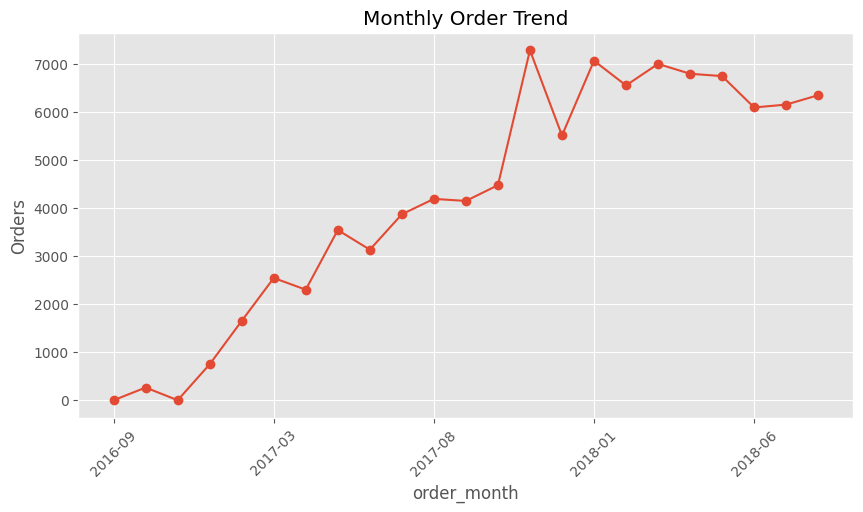

In [ ]:
monthly_orders = master.groupby("order_month")["order_id"].nunique()

plt.figure(figsize=(10,5))
monthly_orders.plot(marker="o")
plt.title("Monthly Order Trend")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

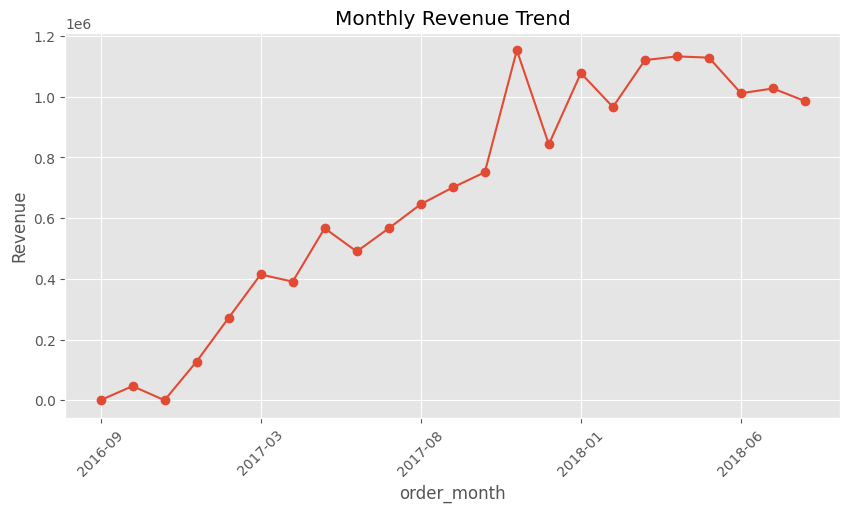

In [ ]:
monthly_rev = master.groupby("order_month")["order_value"].sum()

plt.figure(figsize=(10,5))
monthly_rev.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

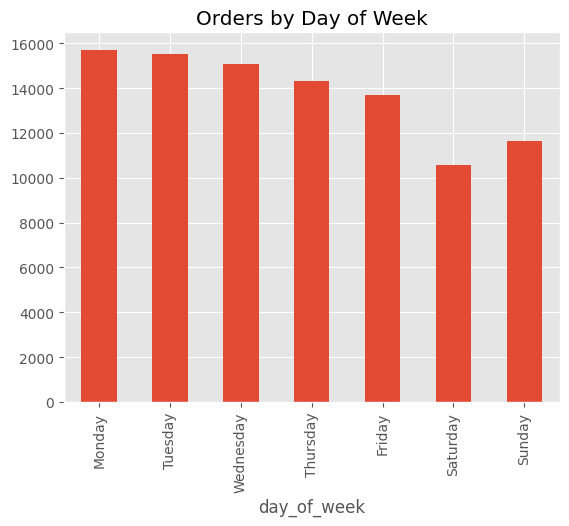

In [ ]:
dow = master.groupby("day_of_week")["order_id"].nunique()

dow = dow.reindex([
    "Monday","Tuesday","Wednesday","Thursday",
    "Friday","Saturday","Sunday"
])

dow.plot(kind="bar")
plt.title("Orders by Day of Week")
plt.show()

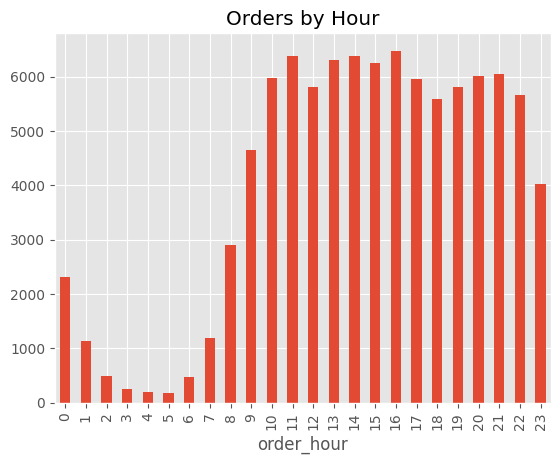

In [ ]:
hourly = master.groupby("order_hour")["order_id"].nunique()

hourly.plot(kind="bar")
plt.title("Orders by Hour")
plt.show()

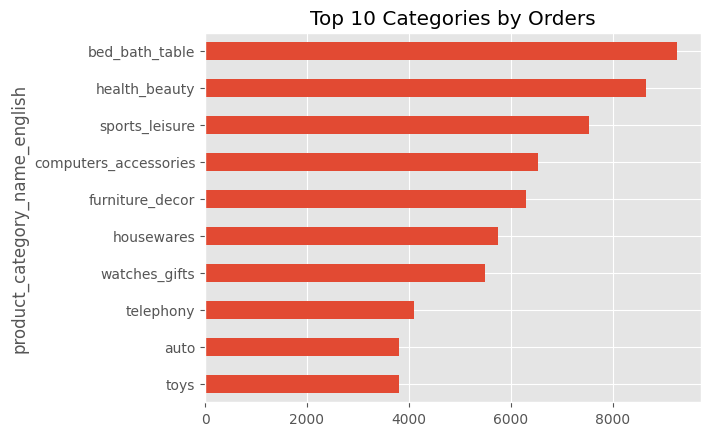

In [ ]:
top_cat = (
    master.groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_cat.sort_values().plot(kind="barh")
plt.title("Top 10 Categories by Orders")
plt.show()

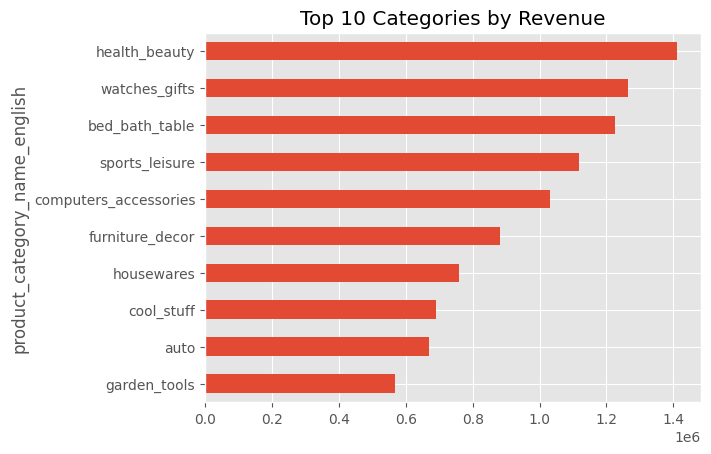

In [ ]:
top_rev = (
    master.groupby("product_category_name_english")["order_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_rev.sort_values().plot(kind="barh")
plt.title("Top 10 Categories by Revenue")
plt.show()

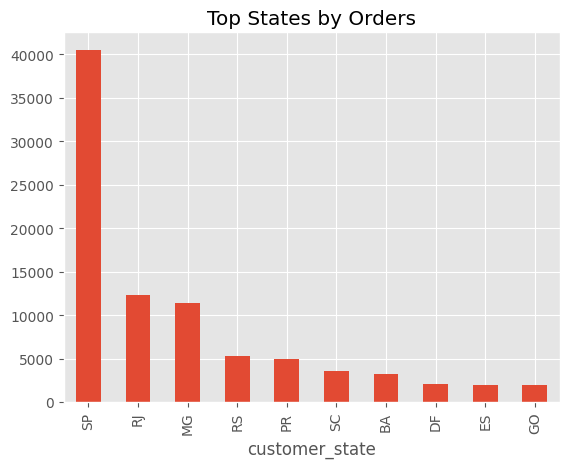

In [ ]:
state_orders = master.groupby("customer_state")["order_id"].nunique().sort_values(ascending=False)

state_orders.head(10).plot(kind="bar")
plt.title("Top States by Orders")
plt.show()

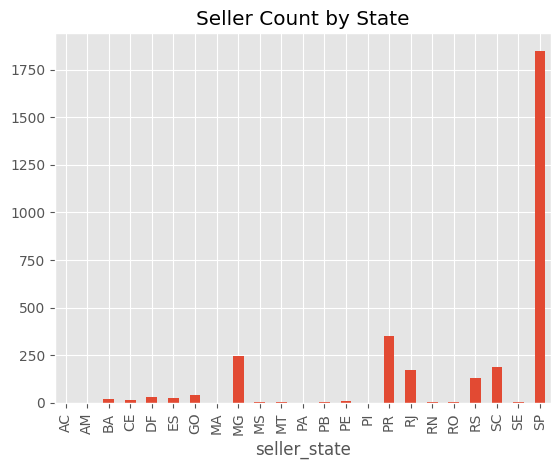

In [ ]:
seller_state = sellers.groupby("seller_state")["seller_id"].count()

seller_state.plot(kind="bar")
plt.title("Seller Count by State")
plt.show()

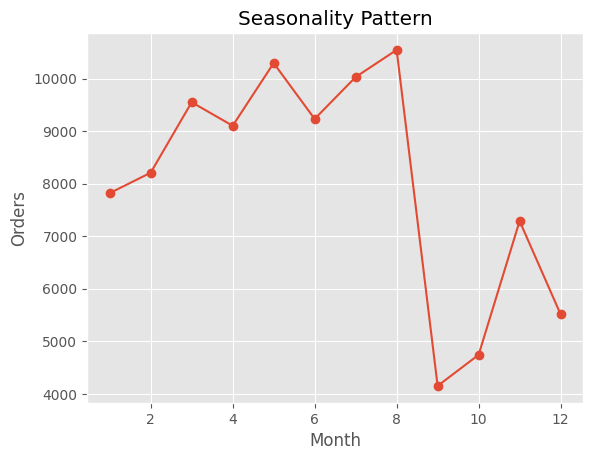

In [ ]:
master["month_num"] = master["order_purchase_timestamp"].dt.month

season = master.groupby("month_num")["order_id"].nunique()

season.plot(marker="o")
plt.title("Seasonality Pattern")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.show()

In [ ]:
master.to_csv(DATA_PATH + "master_clean_m1.csv", index=False)
print("Saved master_clean_m1.csv ✅")

Saved master_clean_m1.csv ✅
